In [15]:
!unzip -q dataset.zip -d ./brain_tumor_dataset

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [16]:
import tensorflow as tf
import cv2
import os
import hashlib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# المسار هيقرأ من الفولدر اللي اتعمله Unzip مباشرة
BASE_DIR = './brain_tumor_dataset'

yes_dir = os.path.join(BASE_DIR, 'yes')
no_dir = os.path.join(BASE_DIR, 'no')


In [17]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

def load_images_and_labels(directory, label):
    images = []
    labels = []
    hashes = []
    image_files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for filename in image_files:
        filepath = os.path.join(directory, filename)

        # md5 hash على البايتات الخام عشان نكتشف نسخ مكررة بالظبط
        with open(filepath, 'rb') as fh:
            file_hash = hashlib.md5(fh.read()).hexdigest()

        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            image = cv2.resize(image, IMAGE_SIZE)
            images.append(image)
            labels.append(label)
            hashes.append(file_hash)
    return images, labels, hashes

print("Loading 'Tumor' images...")
X_yes, y_yes, h_yes = load_images_and_labels(yes_dir, 1)
print(f"Loaded {len(X_yes)} Tumor images.")

print("Loading 'Healthy' images...")
X_no, y_no, h_no = load_images_and_labels(no_dir, 0)
print(f"Loaded {len(X_no)} Healthy images.")

X_all = np.array(X_yes + X_no)
y_all = np.array(y_yes + y_no)
h_all = np.array(h_yes + h_no)

print(f"\nTotal images before dedup: {len(X_all)}")

# ==========================================
# إزالة الصور المكررة بالظبط (نفس الملف بايت-لبايت)
# ==========================================
seen_hashes = {}
keep_indices = []
for i, hh in enumerate(h_all):
    if hh not in seen_hashes:
        seen_hashes[hh] = i
        keep_indices.append(i)

n_removed = len(X_all) - len(keep_indices)
keep_indices = np.array(keep_indices)
X_all = X_all[keep_indices]
y_all = y_all[keep_indices]

print(f"Removed {n_removed} exact-duplicate images.")
print(f"Total images after dedup: {len(X_all)} "
      f"(Tumor: {(y_all == 1).sum()}, Healthy: {(y_all == 0).sum()})")


Loading 'Tumor' images...
Loaded 155 Tumor images.
Loading 'Healthy' images...
Loaded 98 Healthy images.

Total images before dedup: 253
Removed 25 exact-duplicate images.
Total images after dedup: 228 (Tumor: 141, Healthy: 87)


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_all  # يحافظ على نفس نسبة yes/no بين train و validation
)

X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

print(f"Total training images: {len(X_train)}")
print(f"Total validation images: {len(X_val)}")
print(f"Train distribution -> Tumor: {(y_train == 1).sum()}, Healthy: {(y_train == 0).sum()}")
print(f"Val distribution   -> Tumor: {(y_val == 1).sum()}, Healthy: {(y_val == 0).sum()}")

# Class weights عشان نعالج الـ imbalance بين yes/no
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), class_weights_array))
print(f"\nClass weights: {class_weight}")


Total training images: 182
Total validation images: 46
Train distribution -> Tumor: 113, Healthy: 69
Val distribution   -> Tumor: 28, Healthy: 18

Class weights: {np.int64(0): np.float64(1.318840579710145), np.int64(1): np.float64(0.8053097345132744)}


In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(10 / 360),  # حوالي ±10 درجة
], name='augmentation')


In [20]:
from tensorflow.keras import layers, regularizers

L2_REG = 1e-2       # زودناها من 1e-3 لـ 1e-2 عشان نقلل الـ overfitting المتبقي
DROPOUT_RATE = 0.3

tf.keras.backend.clear_session()

inputs = tf.keras.Input(shape=(64, 64, 1))
x = data_augmentation(inputs)
x = layers.Flatten()(x)

for units in [256, 128]:
    x = layers.Dense(units, activation='relu',
                      kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name='mlp_brain_tumor')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

model.summary()


Model: "mlp_brain_tumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,083,393 (4.13 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
)

n_epochs_ran = len(history.history['loss'])
print(f"\nTraining stopped at epoch {n_epochs_ran}/60 "
      f"({'EarlyStopping triggered' if n_epochs_ran < 60 else 'ran full epochs — EarlyStopping did NOT trigger'})")


Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.6429 - auc: 0.6855 - loss: 7.1340 - precision: 0.7449 - recall: 0.6460 - val_accuracy: 0.6304 - val_auc: 0.8145 - val_loss: 6.7200 - val_precision: 0.6222 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6978 - auc: 0.7796 - loss: 6.5896 - precision: 0.8085 - recall: 0.6726 - val_accuracy: 0.6522 - val_auc: 0.7758 - val_loss: 6.3813 - val_precision: 0.6364 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7253 - auc: 0.8226 - loss: 6.1170 - precision: 0.8387 - recall: 0.6903 - val_accuracy: 0.5870 - val_auc: 0.6756 - val_loss: 6.2350 - val_precision: 0.8462 - val_recall: 0.3929 - learning_rate: 0.0010
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7747 - auc: 0.8612 - loss: 5.7136 - precision: 0.8750 - recall: 0.7434 - val_accuracy: 0.7391 - val_auc: 0.6994 - val_loss: 5.8156 - val_precision: 

In [22]:
model.save("mlp_model.keras")
print("Model saved successfully as mlp_model.keras")


Model saved successfully as mlp_model.keras


In [23]:
val_loss, val_acc, val_auc_m, val_prec, val_rec = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss:      {val_loss:.4f}")
print(f"Validation Accuracy:  {val_acc:.4f}")
print(f"Validation AUC:       {val_auc_m:.4f}")
print(f"Validation Precision: {val_prec:.4f}")
print(f"Validation Recall:    {val_rec:.4f}")


Validation Loss:      3.5844
Validation Accuracy:  0.8261
Validation AUC:       0.8333
Validation Precision: 0.8571
Validation Recall:    0.8571


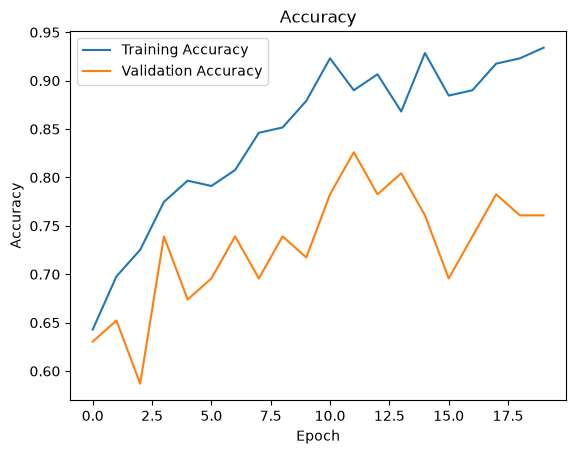

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()


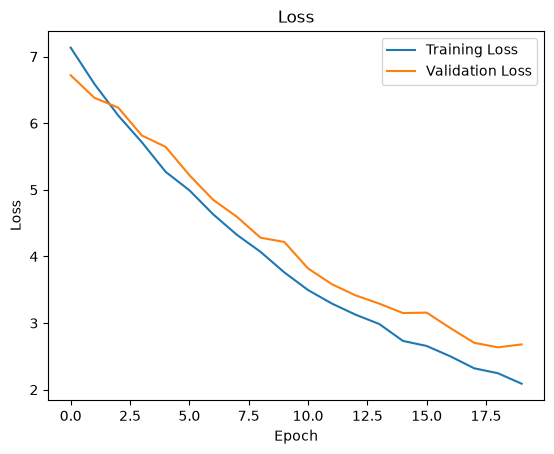

In [25]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()


Confusion Matrix:
[[14  4]
 [ 4 24]]


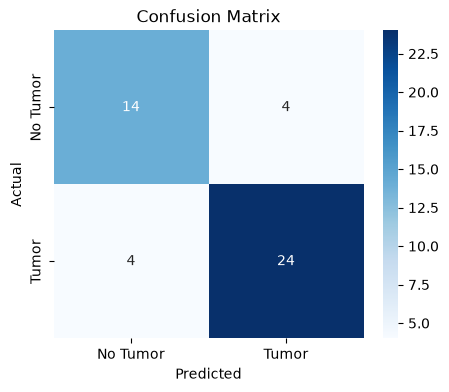


Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.78      0.78      0.78        18
       Tumor       0.86      0.86      0.86        28

    accuracy                           0.83        46
   macro avg       0.82      0.82      0.82        46
weighted avg       0.83      0.83      0.83        46

ROC-AUC: 0.8333


In [31]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score)
import seaborn as sns

val_probs = model.predict(X_val, verbose=0).ravel()
val_preds = (val_probs >= 0.5).astype(int)

cm = confusion_matrix(y_val, val_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=['No Tumor', 'Tumor']))

auc_score = roc_auc_score(y_val, val_probs)
print(f"ROC-AUC: {auc_score:.4f}")


